# Datan siivous ja esikäsittely mallinnusta varten

## 1. kirjastot ja aineiston lataus

In [69]:
#!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

In [70]:
df =pd.read_csv("database_raw.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 15560 entries, 0 to 15559
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Tunniste                   15560 non-null  float64
 1   Ika                        15560 non-null  float64
 2   Sukupuoli                  15560 non-null  float64
 3   Varallisuusindeksi         13359 non-null  float64
 4   Diabetes                   14986 non-null  float64
 5   Pitkaaikaissokeri          9737 non-null   float64
 6   HDL                        10828 non-null  float64
 7   CRP                        11614 non-null  float64
 8   Insuliini                  4625 non-null   float64
 9   Kokonaiskolesteroli        10828 non-null  float64
 10  Triglyseridit              4650 non-null   float64
 11  LDL                        4617 non-null   float64
 12  BMI                        13137 non-null  float64
 13  Vyotaronymparys            12574 non-null  float64
 14  R

In [71]:
df = df.drop_duplicates(subset="Tunniste")
df.shape

(15560, 17)

In [72]:
df.columns

Index(['Tunniste', 'Ika', 'Sukupuoli', 'Varallisuusindeksi', 'Diabetes',
       'Pitkaaikaissokeri', 'HDL', 'CRP', 'Insuliini', 'Kokonaiskolesteroli',
       'Triglyseridit', 'LDL', 'BMI', 'Vyotaronymparys',
       'Reipas_liikunta(pv/vk)', 'Kavely(pv/vk)', 'Istumisaika/paikallaanolo'],
      dtype='str')

## 2. Muuttujien tarkastelu ja visualisointi

In [73]:
df = df.set_index("Tunniste")

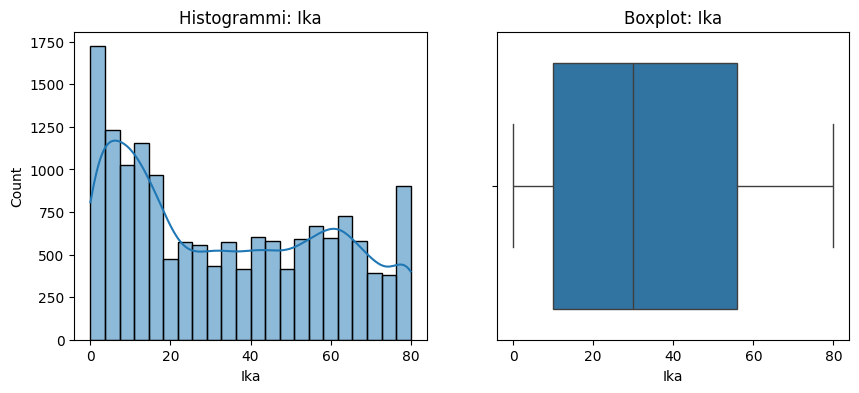

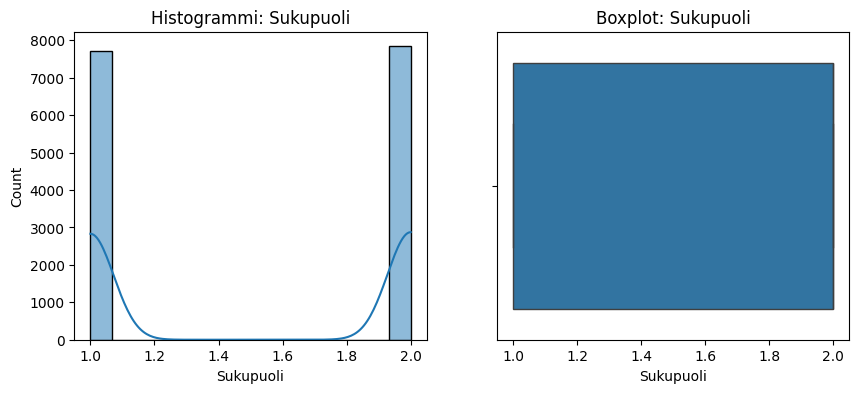

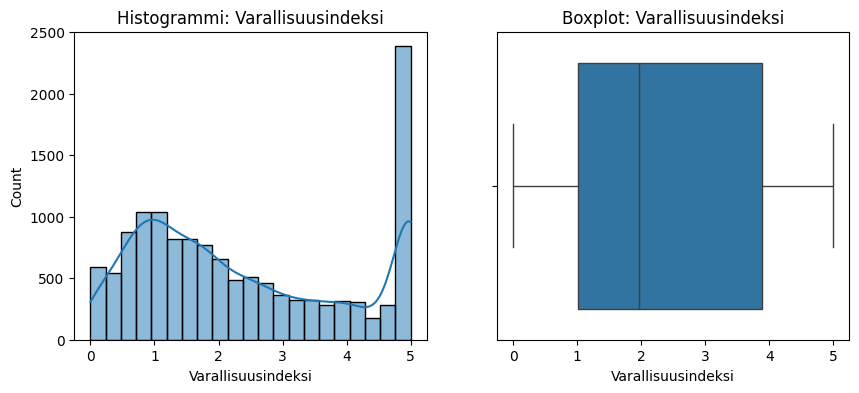

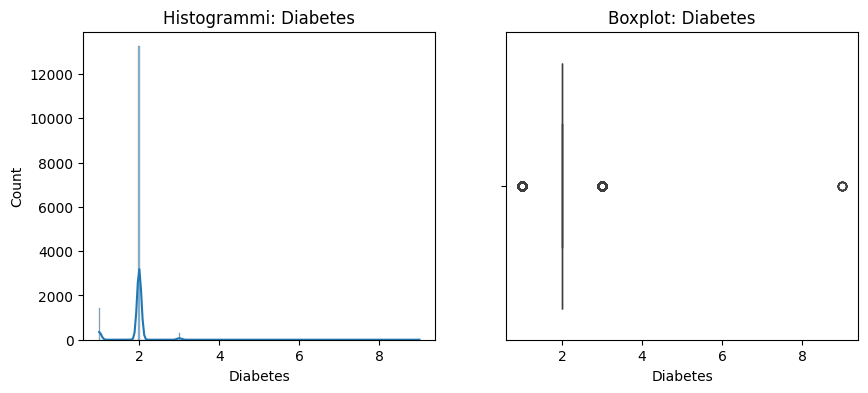

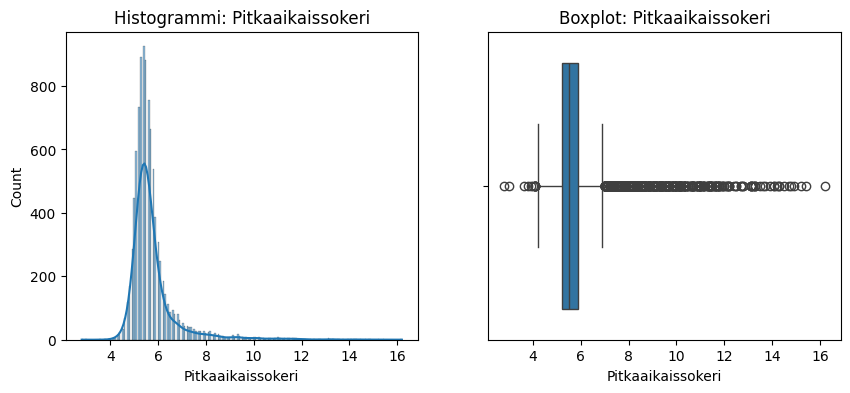

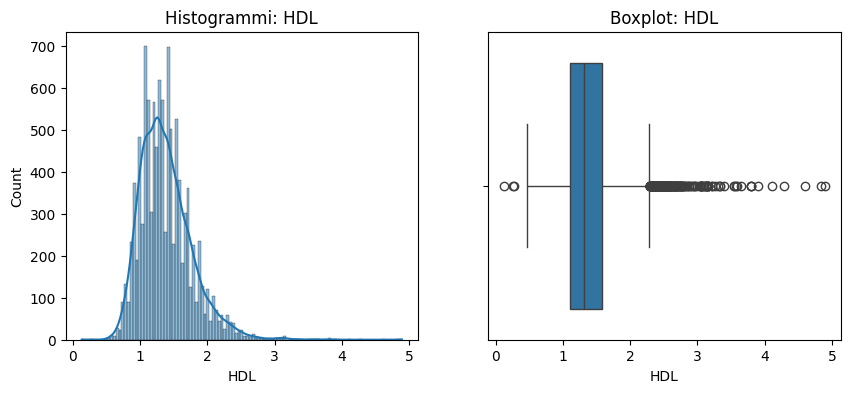

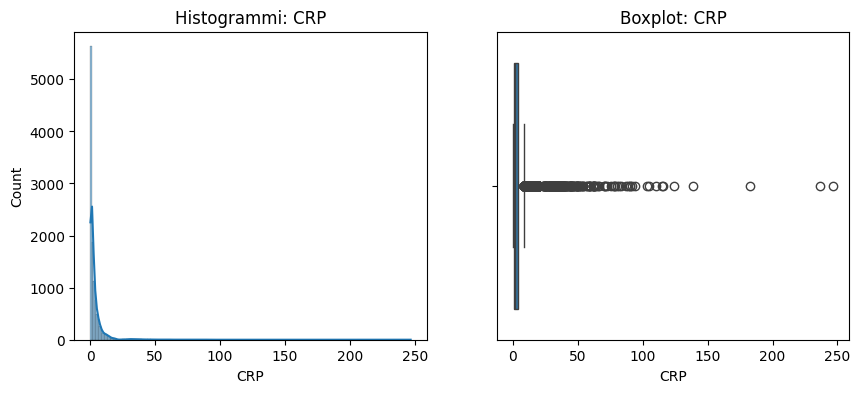

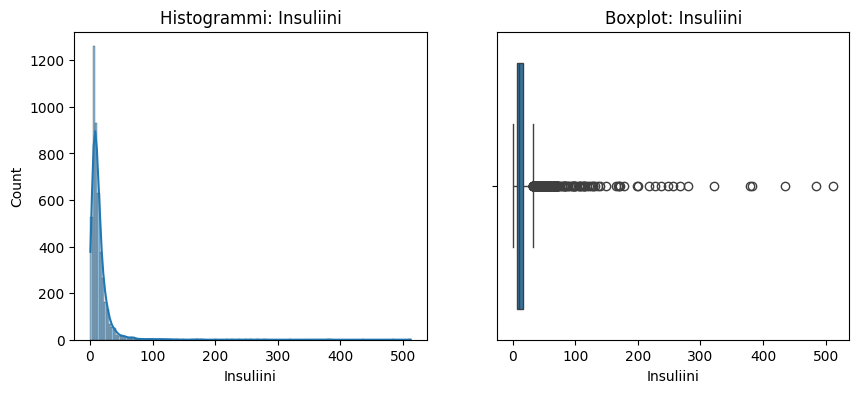

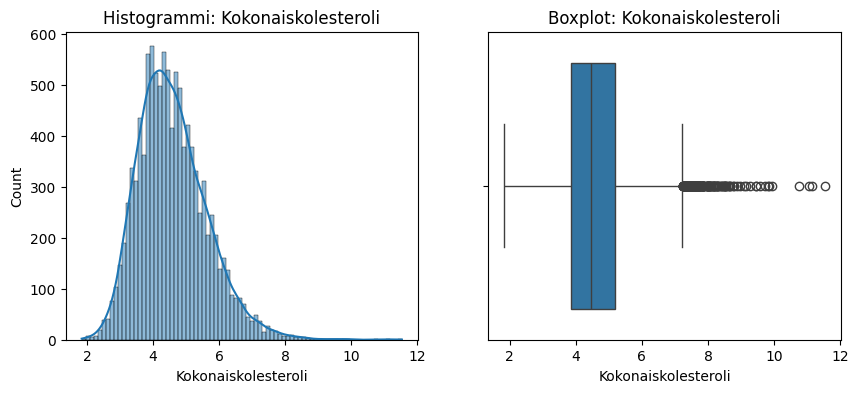

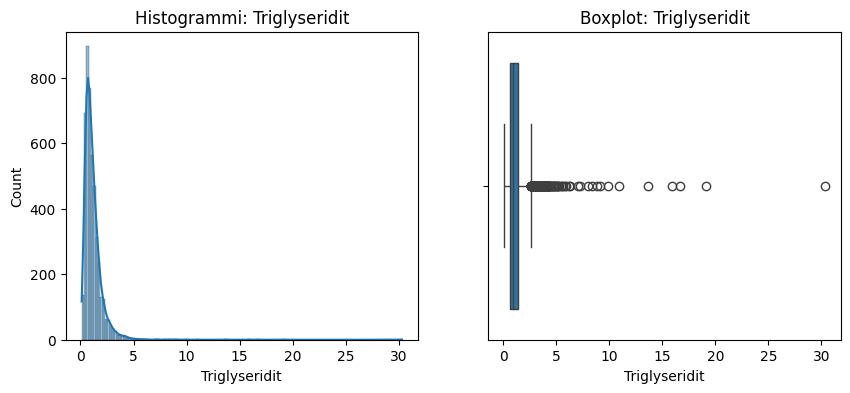

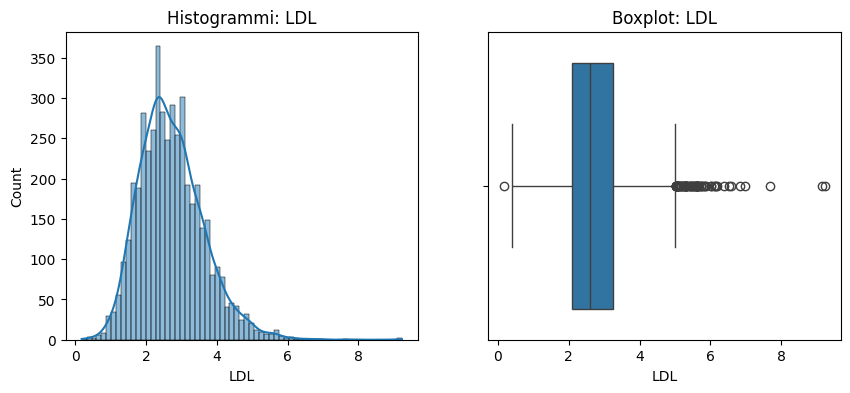

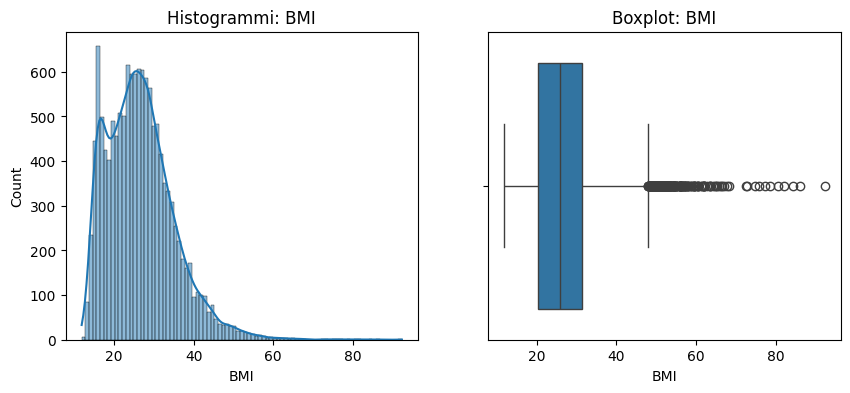

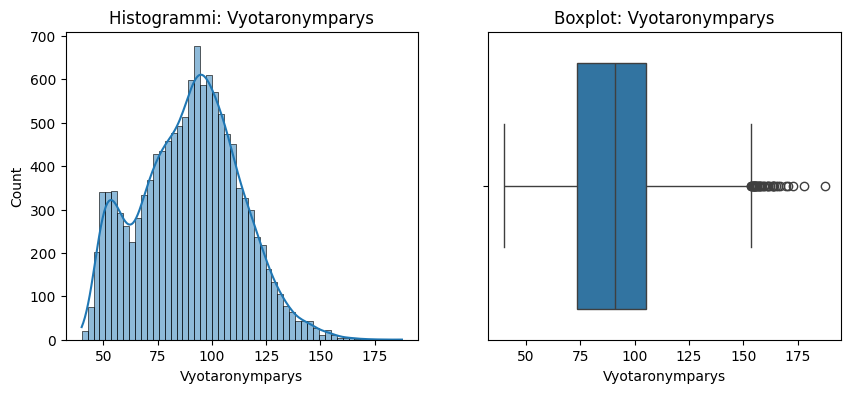

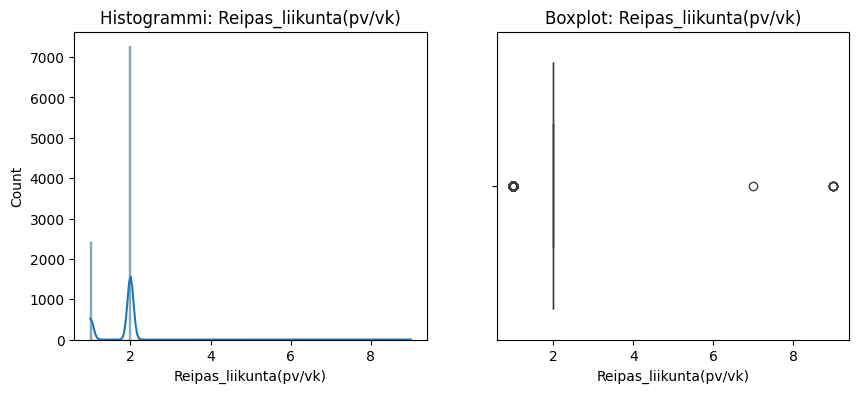

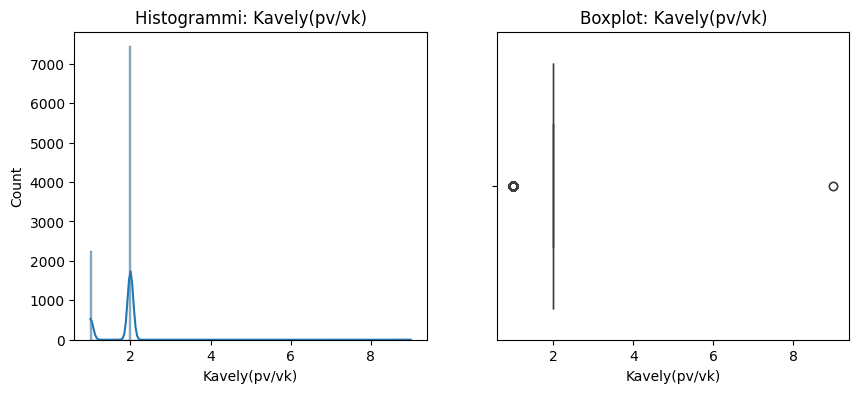

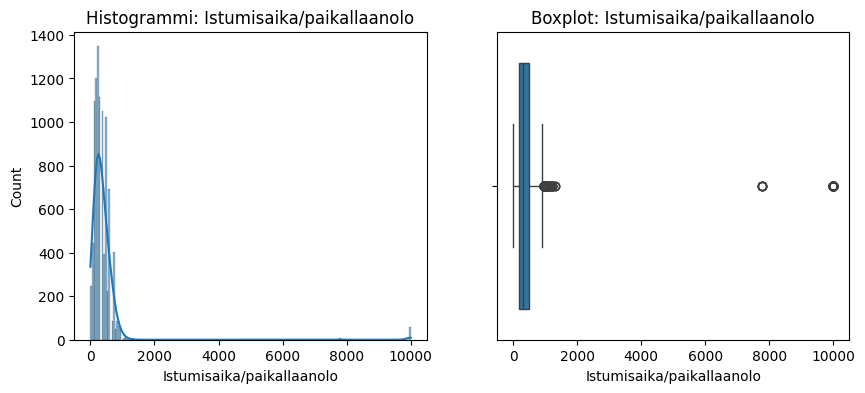

In [74]:
for column in df.columns:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True)
    plt.title(f"Histogrammi: {column}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot: {column}")
    
    plt.show()

## 3. Muuttujien siivous ja käsittely

In [ ]:
#
df["Varallisuusindeksi"].describe()
df["Varallisuusindeksi"].isna().sum()
(df["Varallisuusindeksi"] <0).sum()
df=df[df["Varallisuusindeksi"].between(1,5)] #arvot ovat välillä 1-5
df.shape


count    3090.000000
mean        3.035181
std         1.433273
min         1.000000
25%         1.700000
50%         2.730000
75%         4.690000
max         5.000000
Name: Varallisuusindeksi, dtype: float64

In [76]:
#Poistetaan tyhjät arvot
df["Pitkaaikaissokeri"].isna().sum()
(df["Pitkaaikaissokeri"] <0).sum()
df = df.dropna(subset=["Pitkaaikaissokeri"])
df.shape

(6693, 16)

In [77]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot
df["HDL"].isna().sum() #151 puutuvaa arvoa
(df["HDL"] <0).sum()
imputer_hdl = SimpleImputer(strategy='median') 
df["HDL"] = imputer_hdl.fit_transform(df[["HDL"]])
df.shape




(6693, 16)

In [78]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot
df["CRP"].isna().sum() #209 puuttuvaa arvoa
(df["CRP"] <0).sum()
imputer_crp = SimpleImputer(strategy='median')  
df["CRP"] = imputer_crp.fit_transform(df[["CRP"]])
df.shape

(6693, 16)

In [ ]:
#Poistetaan tyhjät arvot
df["Insuliini"].isna().sum() # 3518 arvoa (en tiedä miten niitä voisi muuten käsitellä -Z imputointi muuttaa liikaa muutujan jakaumaa virheellisesti mielestäni)
(df["Insuliini"] <0).sum()
df = df.dropna(subset=["Insuliini"])
df.shape



(3175, 16)

In [80]:
#Poistetaan tyhjät arvot
df["Kokonaiskolesteroli"].isna().sum() # 1 arvo
(df["Kokonaiskolesteroli"] <0).sum()
df = df.dropna(subset=["Kokonaiskolesteroli"])
df.shape


(3174, 16)

In [81]:
#Muuttujalle ei tarvitse tehdä mitään, kun kaikki arvot löytyivät
df["Triglyseridit"].isna().sum()
(df["Triglyseridit"] <0).sum()
df.shape


(3174, 16)

In [82]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot
df["LDL"].isna().sum() # 24 arvoa
(df["LDL"] <0).sum()
imputer_ldl = SimpleImputer(strategy='median')
df["LDL"] = imputer_ldl.fit_transform(df[["LDL"]])
df.shape

(3174, 16)

In [83]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot
df["BMI"].isna().sum() # 41 arvoa
(df["BMI"] <0).sum()
imputer_bmi = SimpleImputer(strategy="median")
df["BMI"] = imputer_bmi.fit_transform(df[["BMI"]])
df.shape

(3174, 16)

In [84]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot
df["Vyotaronymparys"].isna().sum() #107 aroa
(df["Vyotaronymparys"] <0).sum()
imputer_bmi = SimpleImputer(strategy="median")
df["Vyotaronymparys"] = imputer_bmi.fit_transform(df[["Vyotaronymparys"]])
df.shape


(3174, 16)

In [85]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot sekä arvot 9
df["Reipas_liikunta(pv/vk)"].unique() # 1. , Nan, 2. , 9.
(df["Reipas_liikunta(pv/vk)"] <0).sum()
imputer_rl = SimpleImputer(strategy='median')
df["Reipas_liikunta(pv/vk)"] = imputer_rl.fit_transform(df[["Reipas_liikunta(pv/vk)"]])
df =df[df["Reipas_liikunta(pv/vk)"] !=9] #poistetaan arvo 9 joka viheellinnen, koska lasketaan pv/vk arvoja)
df.shape

(3172, 16)

In [86]:
#Lasketaan mediaani ja korvataan sillä kaikki "NaN"-arvot sekä arvot 9
df["Kavely(pv/vk)"].unique()
(df["Kavely(pv/vk)"] <0).sum()
imputer_k = SimpleImputer(strategy='median')
df["Kavely(pv/vk)"] = imputer_k.fit_transform(df[["Kavely(pv/vk)"]])
df =df[df["Kavely(pv/vk)"] !=9] #poistetaan arvo 9 joka viheellinnen, koska lasketaan pv/vk arvoja)
df.shape

(3171, 16)

In [87]:
df["Istumisaika/paikallaanolo"].isna().sum() # 359 arvoa
(df["Istumisaika/paikallaanolo"] <0).sum()
imputer_i = SimpleImputer(strategy='median')
df["Istumisaika/paikallaanolo"] = imputer_i.fit_transform(df[["Istumisaika/paikallaanolo"]])
df.shape




(3171, 16)

In [88]:
df["Diabetes"].value_counts() #selitettävä muuttuja
df = df[df["Diabetes"].isin([1, 2])]
df["Diabetes"] = df["Diabetes"].map({1: 1, 2: 0} ) # 0 = "Ei diabetestä", 1 = "Diabetes"
df["Diabetes"].unique()
df["Diabetes"].value_counts()


Diabetes
0    2653
1     437
Name: count, dtype: int64

In [89]:
df.shape

(3090, 16)

## 4. Esikäsitellyn aineiston tarkistus ja tallennus

In [90]:
puuttuvat = pd.DataFrame({
   "muuttuja": df.columns,
   "puuttuvat": df.isna().sum(),
   "prosentti": (df.isna().sum() / len(df)) * 100,
   "havaintoja": len(df)
})
puuttuvat

,muuttuja,puuttuvat,prosentti,havaintoja
Ika,Ika,0,0.0,3090
Sukupuoli,Sukupuoli,0,0.0,3090
Varallisuusindeksi,Varallisuusindeksi,0,0.0,3090
Diabetes,Diabetes,0,0.0,3090
Pitkaaikaissokeri,Pitkaaikaissokeri,0,0.0,3090
HDL,HDL,0,0.0,3090
CRP,CRP,0,0.0,3090
Insuliini,Insuliini,0,0.0,3090
Kokonaiskolesteroli,Kokonaiskolesteroli,0,0.0,3090
Triglyseridit,Triglyseridit,0,0.0,3090


In [91]:
df.to_csv("database_original.csv", index=False)